In [14]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib
#%pip install tensorflow scikit-learn 

In [28]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import matplotlib.pyplot as plt

In [16]:
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv('../../dataset_ml.csv')

#df.drop(columns=['Date'], inplace=True)  # Eliminar columna de fecha
df.head()

,oro_return,precio,inflacion_usa,volatilidad_6m,lag_3,tipos_ecb,eurusd,activo_return,desempleo,sp500_return,...,inflacion_usa_lag1,inflacion_usa_lag3,inflacion_usa_lag6,vix_lag1,vix_lag2,vix_lag3,desempleo_lag1,desempleo_lag3,curva10Y2Y_lag1,curva10Y2Y_lag3
0,0.047631,0.320155,0.020352,0.088742,-0.083592,1.0,1.259002,0.021998,5.7,0.050766,...,0.020348,0.020352,0.020352,18.234399,18.309999,18.309999,5.7,5.7,2.42505,2.43000
1,-0.032475,0.337983,0.020263,0.081350,0.104730,1.0,1.245206,0.055686,5.7,0.017276,...,0.020352,0.020352,0.020352,18.309999,18.234399,18.309999,5.7,5.7,2.43000,2.43000
2,0.022960,0.358358,0.016885,0.079723,-0.086500,1.0,1.253007,0.060284,5.6,0.012209,...,0.020263,0.020348,0.020352,16.629999,18.309999,18.234399,5.7,5.7,2.32000,2.42505
3,0.038561,0.405100,0.017401,0.076144,0.021998,1.0,1.231300,0.130434,5.8,-0.016359,...,0.016885,0.020352,0.020352,14.550000,16.629999,18.309999,5.6,5.7,2.33000,2.43000
4,-0.094313,0.386223,0.022926,0.078530,0.055686,1.0,1.198294,-0.046598,5.6,-0.016791,...,0.017401,0.020263,0.020352,16.740000,14.550000,16.629999,5.8,5.7,2.26000,2.32000


In [17]:
n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train = df.iloc[:n_train]
val = df.iloc[n_train:n_train + n_val]
test = df.iloc[n_train + n_val:]

In [18]:
feature_cols = [c for c in df.columns if c != 'target']

X_train_lgb = train[feature_cols]
y_train_lgb = train['target']
X_val_lgb = val[feature_cols]
y_val_lgb = val['target']
X_test_lgb = test[feature_cols]
y_test_lgb = test['target']

print(f"Train: {X_train_lgb.shape}, Val: {X_val_lgb.shape}, Test: {X_test_lgb.shape}")


Train: (185, 26), Val: (39, 26), Test: (41, 26)


In [19]:
# Para LSTM: necesitamos la columna 'precio' en secuencia
precio_train = train['precio'].values
precio_val = val['precio'].values
precio_test = test['precio'].values

In [20]:
INPUT_LENGTH = 6  # Ventana de 6 meses

def crear_secuencias_precio(precios, input_length):
    X_seq = []
    for i in range(len(precios) - input_length):
        X_seq.append(precios[i:i+input_length])
    return np.array(X_seq).reshape(-1, input_length, 1)

X_train_seq = crear_secuencias_precio(precio_train, INPUT_LENGTH)
X_val_seq = crear_secuencias_precio(precio_val, INPUT_LENGTH)
X_test_seq = crear_secuencias_precio(precio_test, INPUT_LENGTH)

# Ajustar targets para que coincidan con las secuencias (recortar primeras INPUT_LENGTH)
y_train_seq = y_train_lgb.iloc[INPUT_LENGTH:].values
y_val_seq = y_val_lgb.iloc[INPUT_LENGTH:].values
y_test_seq = y_test_lgb.iloc[INPUT_LENGTH:].values

In [21]:
# Escalar para LSTM
scaler_lstm = StandardScaler()
X_train_reshaped = X_train_seq.reshape(-1, 1)
X_val_reshaped = X_val_seq.reshape(-1, 1)
X_test_reshaped = X_test_seq.reshape(-1, 1)

scaler_lstm.fit(X_train_reshaped)
X_train_scaled = scaler_lstm.transform(X_train_reshaped).reshape(X_train_seq.shape)
X_val_scaled = scaler_lstm.transform(X_val_reshaped).reshape(X_val_seq.shape)
X_test_scaled = scaler_lstm.transform(X_test_reshaped).reshape(X_test_seq.shape)

In [22]:
# Construir LSTM extractor de features
lstm_input = Input(shape=(INPUT_LENGTH, 1))
x = LSTM(16, return_sequences=True, dropout=0.2)(lstm_input)
x = LSTM(8, return_sequences=False, dropout=0.2)(x)
feature_extractor = Model(inputs=lstm_input, outputs=x)

In [23]:
# Modelo completo para entrenar
output = Dense(1)(x)
lstm_model = Model(inputs=lstm_input, outputs=output)
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 6, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 6, 16)          │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,961 (7.66 KB)

 Trainable params: 1,961 (7.66 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Entrenar LSTM
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lstm_model.fit(
    X_train_scaled, y_train_seq,
    validation_data=(X_val_scaled, y_val_seq),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0122 - val_loss: 0.0182
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0095 - val_loss: 0.0157
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0099 - val_loss: 0.0115
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0089 - val_loss: 0.0105
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 - val_loss: 0.0102
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 - val_loss: 0.0095
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0096 - val_loss: 0.0095
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0091 - val_loss: 0.0097
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 - val_loss: 0.0099
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0092 - val_loss: 0.0096
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0093 - val_loss: 0.0095
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

In [25]:
# Extraer features LSTM
lstm_features_train = feature_extractor.predict(X_train_scaled, verbose=0)
lstm_features_val = feature_extractor.predict(X_val_scaled, verbose=0)
lstm_features_test = feature_extractor.predict(X_test_scaled, verbose=0)

# Preparar datos híbridos (LGBM + features LSTM)
X_train_hybrid = np.hstack([X_train_lgb.iloc[INPUT_LENGTH:].values, lstm_features_train])
X_val_hybrid = np.hstack([X_val_lgb.iloc[INPUT_LENGTH:].values, lstm_features_val])
X_test_hybrid = np.hstack([X_test_lgb.iloc[INPUT_LENGTH:].values, lstm_features_test])

# Entrenar LightGBM híbrido
lgb_hybrid = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbose=-1
)

lgb_hybrid.fit(X_train_hybrid, y_train_seq)

# Evaluar
y_pred_hybrid = lgb_hybrid.predict(X_test_hybrid)

c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


loss: 0.0710 - mae: 0.2080 - val_loss: 0.0732 - val_mae: 0.2275 - learning_rate: 5.0000e-04

In [26]:
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

print("\n=== MODELO HÍBRIDO LSTM + LIGHTGBM ===")
print(f"MAE: {mean_absolute_error(y_test_seq, y_pred_hybrid):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_seq, y_pred_hybrid)):.4f}")
print(f"R²: {r2_score(y_test_seq, y_pred_hybrid):.4f}")
print(f"DA: {directional_accuracy(y_test_seq, y_pred_hybrid):.4f}")


=== MODELO HÍBRIDO LSTM + LIGHTGBM ===
MAE: 0.0575
RMSE: 0.0716
R²: -0.4571
DA: 0.5714


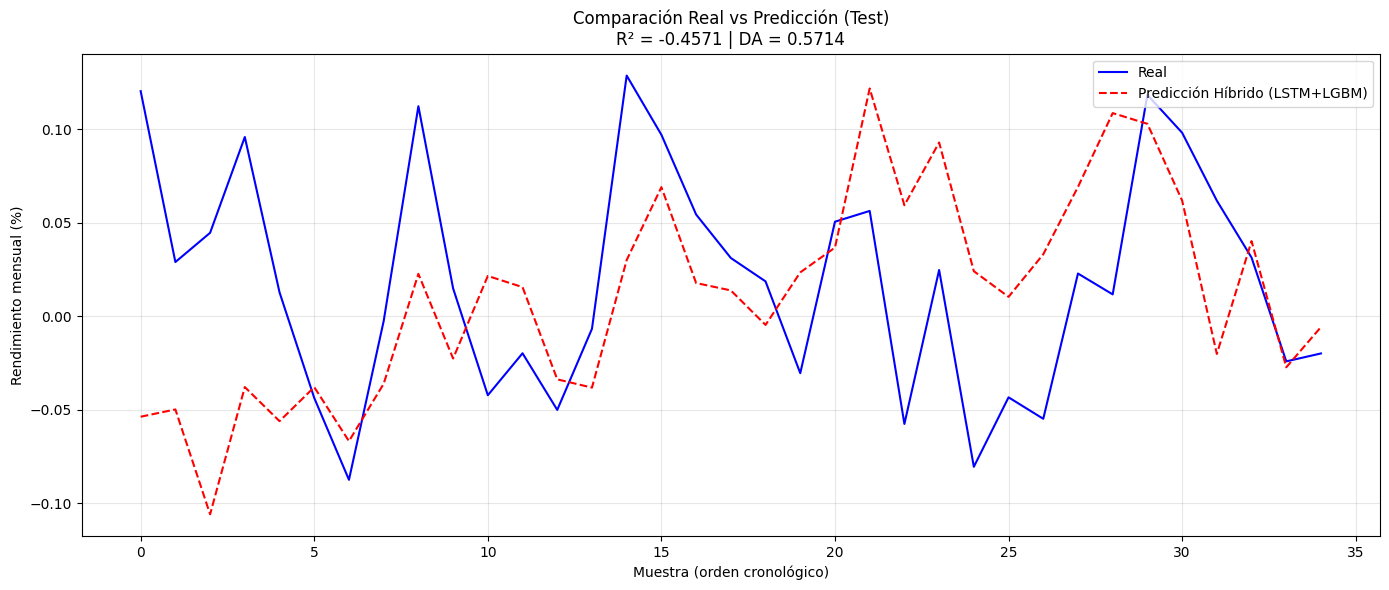

In [29]:
# %%
# ============================================
# GRÁFICA: REAL vs PREDICCIÓN (MODELO HÍBRIDO)
# ============================================

plt.figure(figsize=(14, 6))

# Mostrar muestras (últimas 100 o todas si son menos)
n_mostrar = min(100, len(y_test_seq))

# Crear índice para el eje X
indices = range(n_mostrar)

# Graficar
plt.plot(indices, y_test_seq[:n_mostrar], 
         label='Real', color='blue', linewidth=1.5)
plt.plot(indices, y_pred_hybrid[:n_mostrar], 
         label='Predicción Híbrido (LSTM+LGBM)', 
         color='red', linestyle='--', linewidth=1.5)

# Personalizar gráfica
plt.title(f'Comparación Real vs Predicción (Test)\nR² = {r2_score(y_test_seq, y_pred_hybrid):.4f} | DA = {directional_accuracy(y_test_seq, y_pred_hybrid):.4f}', 
          fontsize=12)
plt.xlabel('Muestra (orden cronológico)', fontsize=10)
plt.ylabel('Rendimiento mensual (%)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Guardar (opcional)
plt.savefig('hibrido_real_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()